In [1]:
# ============================================================
# AEROPURE — WEEK 9
# POLLUTION REGIME CLUSTERING
# ============================================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans, DBSCAN
from sklearn.metrics import silhouette_score

print("Week 9 libraries imported successfully.")

Week 9 libraries imported successfully.


In [2]:
# ============================================================
# W9 CELL 2 — LOAD FEATURE-ENGINEERED DATA
# ============================================================

train_fe = pd.read_csv("../data/train_fe_w6.csv")
test_fe = pd.read_csv("../data/test_fe_w6.csv")

# Convert Date back to datetime
train_fe["Date"] = pd.to_datetime(train_fe["Date"])
test_fe["Date"] = pd.to_datetime(test_fe["Date"])

print("Training shape:", train_fe.shape)
print("Test shape:", test_fe.shape)

print("\nTraining date range:")
print(train_fe["Date"].min(), "to", train_fe["Date"].max())

print("\nTest date range:")
print(test_fe["Date"].min(), "to", test_fe["Date"].max())

Training shape: (15636, 22)
Test shape: (8681, 22)

Training date range:
2015-01-02 00:00:00 to 2019-05-25 00:00:00

Test date range:
2019-05-26 00:00:00 to 2020-06-30 00:00:00


In [3]:
# ============================================================
# W9 CELL 3 — SELECT POLLUTION FEATURES
# ============================================================

pollution_features = [
    "PM2.5",
    "PM10",
    "NO",
    "NO2",
    "NOx",
    "NH3",
    "CO",
    "SO2",
    "O3",
    "Benzene",
    "Toluene",
    "Xylene"
]

# Keep only columns that exist in the dataset
POLLUTION_FEATURES = [
    col for col in pollution_features
    if col in train_fe.columns
]

print("Pollution features selected:")
print(POLLUTION_FEATURES)

print("\nNumber of pollution features:",
      len(POLLUTION_FEATURES))

Pollution features selected:
['PM2.5', 'PM10', 'NO', 'NO2', 'NOx', 'NH3', 'CO', 'SO2', 'O3', 'Benzene', 'Toluene', 'Xylene']

Number of pollution features: 12


In [4]:
# ============================================================
# W9 CELL 4 — INSPECT POLLUTION DATA
# ============================================================

print("First 5 rows:")
display(train_fe[POLLUTION_FEATURES].head())

print("\nMissing values:")
display(train_fe[POLLUTION_FEATURES].isna().sum())

print("\nSummary statistics:")
display(train_fe[POLLUTION_FEATURES].describe().round(2))

First 5 rows:


,PM2.5,PM10,NO,NO2,NOx,NH3,CO,SO2,O3,Benzene,Toluene,Xylene
0,186.18,269.55,62.09,32.87,88.14,31.83,9.54,6.65,29.97,10.55,20.09,4.29
1,87.18,131.90,25.73,30.31,47.95,69.55,10.61,2.65,19.71,3.91,10.23,1.99
2,151.84,241.84,25.01,36.91,48.62,130.36,11.54,4.63,25.36,4.26,9.71,3.34
3,146.60,219.13,14.01,34.92,38.25,122.88,9.20,3.33,23.20,2.80,6.21,2.96
4,149.58,252.10,17.21,37.84,42.46,134.97,9.44,3.66,26.83,3.63,7.35,3.47



Missing values:


PM2.5       483
PM10       6135
NO          193
NO2         182
NOx        1398
NH3        5216
CO          190
SO2         434
O3          458
Benzene    2204
Toluene    3181
Xylene     9890
dtype: int64


Summary statistics:


,PM2.5,PM10,NO,NO2,NOx,NH3,CO,SO2,O3,Benzene,Toluene,Xylene
count,15153.00,9501.00,15443.00,15454.00,14238.00,10420.00,15446.00,15202.00,15178.00,13432.00,12455.00,5746.00
mean,78.37,140.67,18.66,32.09,33.84,27.83,2.73,14.71,36.41,2.67,8.96,4.02
std,68.78,98.31,23.51,25.11,32.46,30.47,7.89,17.83,22.90,6.91,15.12,6.29
min,1.72,0.02,0.06,0.01,0.00,0.02,0.00,0.26,0.10,0.00,0.00,0.00
25%,35.95,75.33,6.08,14.31,13.25,10.34,0.64,5.41,19.75,0.23,1.08,0.40
50%,57.66,111.85,10.43,25.60,24.94,19.88,1.01,8.89,32.26,1.22,3.57,1.47
75%,94.70,174.82,20.80,42.15,42.88,34.89,1.69,16.09,47.97,3.34,10.01,5.50
max,949.99,917.08,287.14,266.46,293.10,352.89,175.81,171.32,257.73,391.88,411.52,125.18


In [6]:
# ============================================================
# W9 — CELL 5
# MISSING VALUE IMPUTATION + STANDARDIZATION
# ============================================================

from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler

# Create imputer
imputer = SimpleImputer(strategy="median")

# Fit on training data and transform training data
X_train_imputed = imputer.fit_transform(
    train_fe[POLLUTION_FEATURES]
)

# Transform test data using training imputer
X_test_imputed = imputer.transform(
    test_fe[POLLUTION_FEATURES]
)

# Create scaler
scaler = StandardScaler()

# Fit on training data and transform
X_train_scaled = scaler.fit_transform(X_train_imputed)

# Transform test data
X_test_scaled = scaler.transform(X_test_imputed)

print("Missing values handled successfully.")
print("Training data shape:", X_train_scaled.shape)
print("Testing data shape :", X_test_scaled.shape)

print("\nTraining scaled mean:")
print(np.round(X_train_scaled.mean(axis=0), 3))

print("\nTraining scaled standard deviation:")
print(np.round(X_train_scaled.std(axis=0), 3))

Missing values handled successfully.
Training data shape: (15636, 12)
Testing data shape : (8681, 12)

Training scaled mean:
[ 0.  0. -0. -0.  0.  0. -0. -0. -0.  0.  0.  0.]

Training scaled standard deviation:
[1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1.]


In [7]:
# ============================================================
# W9 — CELL 6
# PCA
# ============================================================

from sklearn.decomposition import PCA

pca = PCA(n_components=2)

# Fit PCA on training data
X_train_pca = pca.fit_transform(X_train_scaled)

# Transform test data
X_test_pca = pca.transform(X_test_scaled)

print("PCA completed successfully.")

print("\nTraining PCA shape:", X_train_pca.shape)
print("Testing PCA shape :", X_test_pca.shape)

print("\nExplained variance ratio:")
print(np.round(pca.explained_variance_ratio_, 4))

print("\nTotal variance explained:")
print(round(pca.explained_variance_ratio_.sum(), 4))

PCA completed successfully.

Training PCA shape: (15636, 2)
Testing PCA shape : (8681, 2)

Explained variance ratio:
[0.3146 0.1531]

Total variance explained:
0.4677


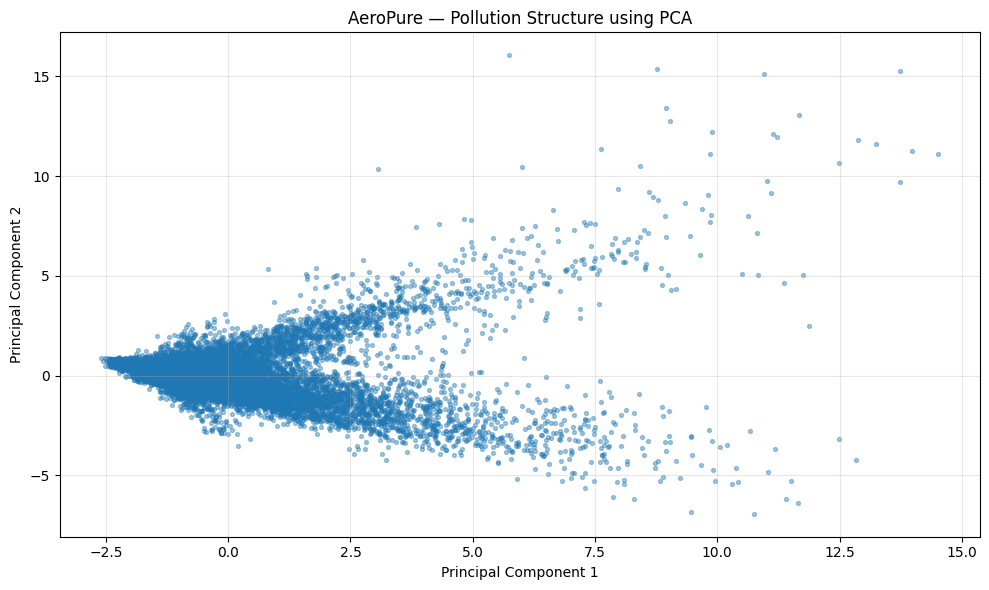

In [8]:
# ============================================================
# W9 — CELL 7
# PCA VISUALIZATION
# ============================================================

plt.figure(figsize=(10, 6))

plt.scatter(
    X_train_pca[:, 0],
    X_train_pca[:, 1],
    s=8,
    alpha=0.4
)

plt.xlabel("Principal Component 1")
plt.ylabel("Principal Component 2")
plt.title("AeroPure — Pollution Structure using PCA")
plt.grid(True, alpha=0.3)

plt.tight_layout()

plt.savefig(
    "../graphs/w9_pca_pollution_structure.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

In [9]:
# ============================================================
# W9 — CELL 8
# K-MEANS — FIND BEST NUMBER OF POLLUTION REGIMES
# ============================================================

from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score

k_values = range(2, 7)

silhouette_scores = []

for k in k_values:

    kmeans = KMeans(
        n_clusters=k,
        random_state=42,
        n_init=10
    )

    labels = kmeans.fit_predict(X_train_scaled)

    score = silhouette_score(
        X_train_scaled,
        labels
    )

    silhouette_scores.append(score)

    print(f"K = {k} | Silhouette Score = {score:.4f}")

K = 2 | Silhouette Score = 0.4622
K = 3 | Silhouette Score = 0.4310
K = 4 | Silhouette Score = 0.2371
K = 5 | Silhouette Score = 0.2533
K = 6 | Silhouette Score = 0.2518


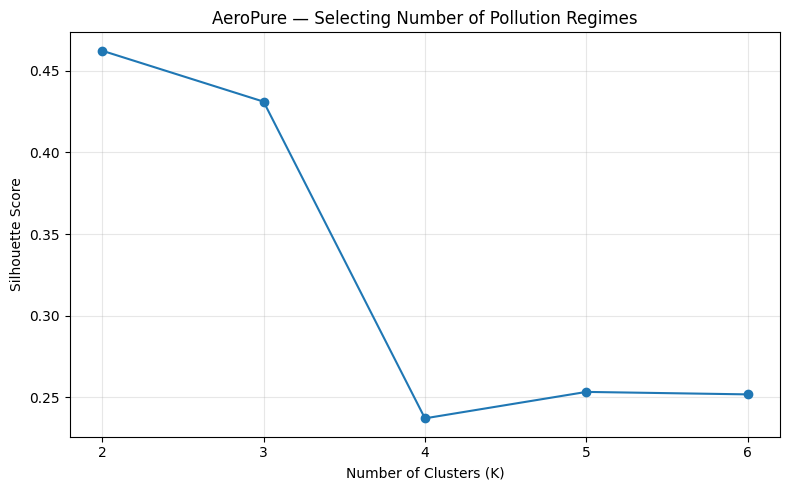

Best K: 2
Best Silhouette Score: 0.4622


In [10]:
# ============================================================
# W9 — CELL 9
# SILHOUETTE SCORE COMPARISON
# ============================================================

plt.figure(figsize=(8, 5))

plt.plot(
    list(k_values),
    silhouette_scores,
    marker="o"
)

plt.xlabel("Number of Clusters (K)")
plt.ylabel("Silhouette Score")
plt.title("AeroPure — Selecting Number of Pollution Regimes")

plt.xticks(list(k_values))
plt.grid(True, alpha=0.3)

plt.tight_layout()

plt.savefig(
    "../graphs/w9_kmeans_silhouette.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

# Select K with highest silhouette score
best_k = list(k_values)[np.argmax(silhouette_scores)]

print("Best K:", best_k)
print("Best Silhouette Score:", round(max(silhouette_scores), 4))

In [11]:
# ============================================================
# W9 — CELL 10
# FINAL K-MEANS POLLUTION REGIMES
# ============================================================

# Create final K-Means model
kmeans_final = KMeans(
    n_clusters=best_k,
    random_state=42,
    n_init=10
)

# Fit on training pollution data
train_regimes = kmeans_final.fit_predict(X_train_scaled)

# Assign regimes to test data
test_regimes = kmeans_final.predict(X_test_scaled)

# Add regime labels to datasets
train_fe["Pollution_Regime"] = train_regimes
test_fe["Pollution_Regime"] = test_regimes

print("K-Means clustering completed successfully.")

print("\nNumber of regimes:", best_k)

print("\nTraining regime distribution:")
print(train_fe["Pollution_Regime"].value_counts().sort_index())

print("\nTesting regime distribution:")
print(test_fe["Pollution_Regime"].value_counts().sort_index())

K-Means clustering completed successfully.

Number of regimes: 2

Training regime distribution:
Pollution_Regime
0    13006
1     2630
Name: count, dtype: int64

Testing regime distribution:
Pollution_Regime
0    7824
1     857
Name: count, dtype: int64


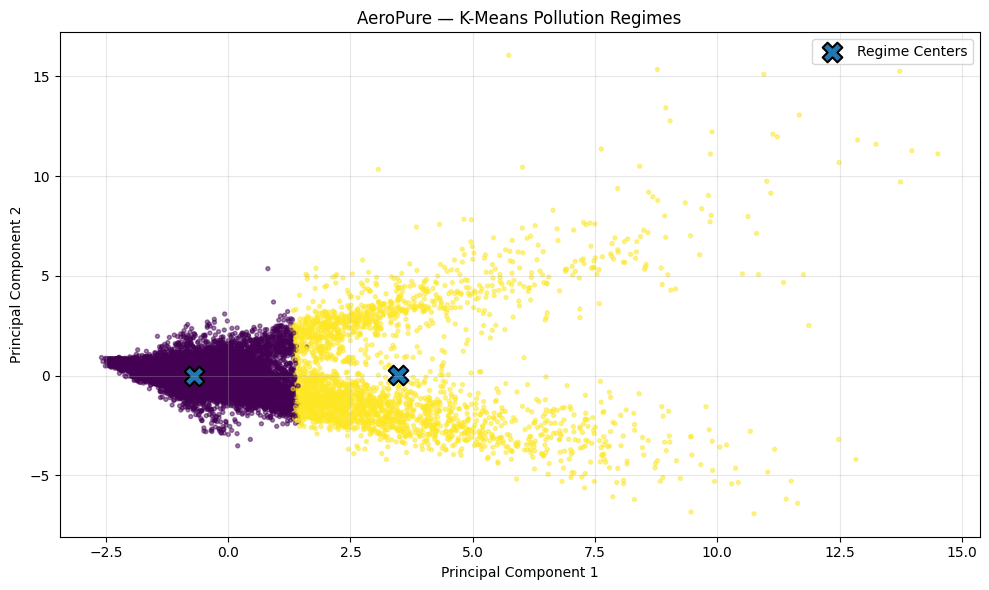

In [12]:
# ============================================================
# W9 — CELL 11
# K-MEANS REGIME VISUALIZATION
# ============================================================

plt.figure(figsize=(10, 6))

plt.scatter(
    X_train_pca[:, 0],
    X_train_pca[:, 1],
    c=train_fe["Pollution_Regime"],
    s=8,
    alpha=0.5
)

# Plot cluster centers in PCA space
centers_pca = pca.transform(kmeans_final.cluster_centers_)

plt.scatter(
    centers_pca[:, 0],
    centers_pca[:, 1],
    marker="X",
    s=200,
    edgecolor="black",
    linewidth=1.5,
    label="Regime Centers"
)

plt.xlabel("Principal Component 1")
plt.ylabel("Principal Component 2")
plt.title("AeroPure — K-Means Pollution Regimes")

plt.legend()
plt.grid(True, alpha=0.3)

plt.tight_layout()

plt.savefig(
    "../graphs/w9_kmeans_clusters.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

In [13]:
# ============================================================
# W9 — CELL 12
# POLLUTION REGIME PROFILE ANALYSIS
# ============================================================

# Calculate mean pollutant concentration for each regime
regime_profile = train_fe.groupby("Pollution_Regime")[
    POLLUTION_FEATURES
].mean()

print("Average pollutant concentration by regime:\n")

display(regime_profile.round(2))

Average pollutant concentration by regime:



,PM2.5,PM10,NO,NO2,NOx,NH3,CO,SO2,O3,Benzene,Toluene,Xylene
Pollution_Regime,,,,,,,,,,,,
0,64.13,113.63,11.78,24.76,24.00,25.55,1.48,11.24,34.07,1.77,5.24,2.68
1,146.49,282.46,52.23,67.92,78.29,41.89,8.89,31.40,48.06,6.45,23.79,7.49


In [14]:
# ============================================================
# W9 — CELL 13
# REGIME COMPARISON
# ============================================================

# Difference between Regime 1 and Regime 0
regime_difference = (
    regime_profile.loc[1] - regime_profile.loc[0]
)

comparison = pd.DataFrame({
    "Regime 0 Mean": regime_profile.loc[0],
    "Regime 1 Mean": regime_profile.loc[1],
    "Difference (1 - 0)": regime_difference
})

display(comparison.round(2))

,Regime 0 Mean,Regime 1 Mean,Difference (1 - 0)
PM2.5,64.13,146.49,82.36
PM10,113.63,282.46,168.83
NO,11.78,52.23,40.45
NO2,24.76,67.92,43.16
NOx,24.00,78.29,54.30
NH3,25.55,41.89,16.34
CO,1.48,8.89,7.41
SO2,11.24,31.40,20.16
O3,34.07,48.06,13.99
Benzene,1.77,6.45,4.68


In [15]:
# ============================================================
# W9 — CELL 14
# DBSCAN PARAMETER COMPARISON
# ============================================================

from sklearn.cluster import DBSCAN

eps_values = [0.5, 0.75, 1.0, 1.25, 1.5]
min_samples = 20

dbscan_results = []

for eps in eps_values:

    dbscan = DBSCAN(
        eps=eps,
        min_samples=min_samples
    )

    labels = dbscan.fit_predict(X_train_scaled)

    n_clusters = len(set(labels)) - (1 if -1 in labels else 0)
    n_noise = np.sum(labels == -1)

    dbscan_results.append({
        "eps": eps,
        "clusters": n_clusters,
        "noise_points": n_noise,
        "noise_percent": round(
            100 * n_noise / len(labels), 2
        )
    })

dbscan_results = pd.DataFrame(dbscan_results)

display(dbscan_results)

,eps,clusters,noise_points,noise_percent
0,0.50,5,10938,69.95
1,0.75,6,6396,40.91
2,1.00,6,3832,24.51
3,1.25,4,2576,16.47
4,1.50,1,1680,10.74


In [16]:
# ============================================================
# W9 — CELL 15
# FINAL DBSCAN MODEL
# ============================================================

dbscan_final = DBSCAN(
    eps=1.25,
    min_samples=20
)

dbscan_labels = dbscan_final.fit_predict(X_train_scaled)

# Number of clusters excluding noise (-1)
n_clusters = len(set(dbscan_labels)) - (
    1 if -1 in dbscan_labels else 0
)

n_noise = np.sum(dbscan_labels == -1)

print("DBSCAN completed successfully.")
print("Number of clusters:", n_clusters)
print("Noise points:", n_noise)
print(
    "Noise percentage:",
    round(100 * n_noise / len(dbscan_labels), 2),
    "%"
)

# Silhouette score only for non-noise points
mask = dbscan_labels != -1

if len(set(dbscan_labels[mask])) >= 2:
    dbscan_silhouette = silhouette_score(
        X_train_scaled[mask],
        dbscan_labels[mask]
    )

    print(
        "Silhouette score (excluding noise):",
        round(dbscan_silhouette, 4)
    )
else:
    print("Silhouette score cannot be calculated.")

DBSCAN completed successfully.
Number of clusters: 4
Noise points: 2576
Noise percentage: 16.47 %
Silhouette score (excluding noise): 0.3399


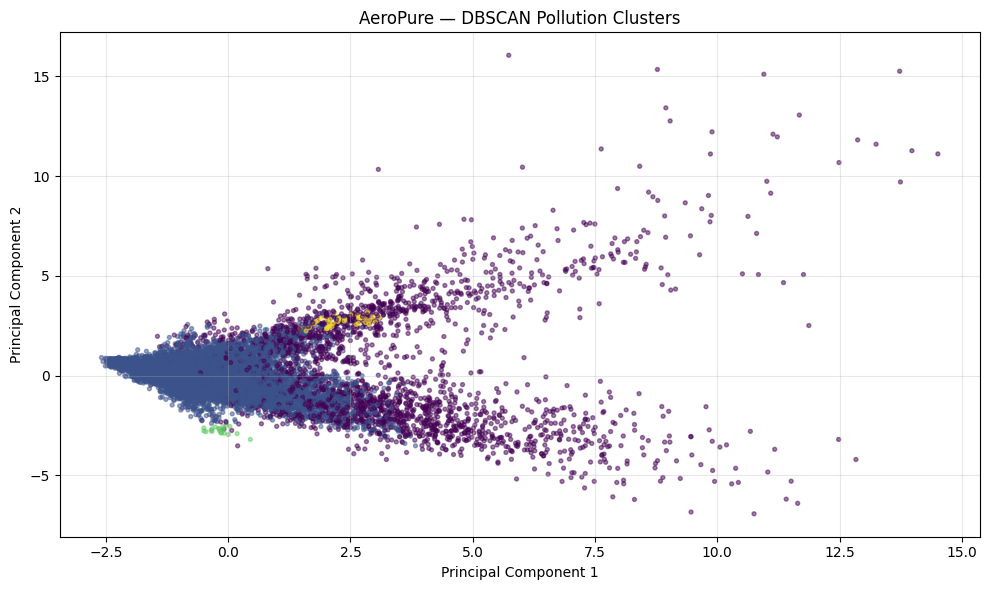

In [17]:
# ============================================================
# W9 — CELL 16
# DBSCAN VISUALIZATION
# ============================================================

plt.figure(figsize=(10, 6))

plt.scatter(
    X_train_pca[:, 0],
    X_train_pca[:, 1],
    c=dbscan_labels,
    s=8,
    alpha=0.5
)

plt.xlabel("Principal Component 1")
plt.ylabel("Principal Component 2")
plt.title("AeroPure — DBSCAN Pollution Clusters")

plt.grid(True, alpha=0.3)

plt.tight_layout()

plt.savefig(
    "../graphs/w9_dbscan_clusters.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

In [18]:
# ============================================================
# W9 — CELL 17
# SAVE WEEK 9 FEATURE-ENGINEERED DATA
# ============================================================

train_w9 = train_fe.copy()
test_w9 = test_fe.copy()

train_w9.to_csv(
    "../data/train_fe_w9.csv",
    index=False
)

test_w9.to_csv(
    "../data/test_fe_w9.csv",
    index=False
)

print("W9 datasets saved successfully.")

print("\nTraining dataset:")
print(train_w9.shape)

print("\nTesting dataset:")
print(test_w9.shape)

print("\nNew feature added:")
print("Pollution_Regime")

print("\nTrain Pollution_Regime distribution:")
print(train_w9["Pollution_Regime"].value_counts().sort_index())

print("\nTest Pollution_Regime distribution:")
print(test_w9["Pollution_Regime"].value_counts().sort_index())

W9 datasets saved successfully.

Training dataset:
(15636, 23)

Testing dataset:
(8681, 23)

New feature added:
Pollution_Regime

Train Pollution_Regime distribution:
Pollution_Regime
0    13006
1     2630
Name: count, dtype: int64

Test Pollution_Regime distribution:
Pollution_Regime
0    7824
1     857
Name: count, dtype: int64


In [19]:
# ============================================================
# W9 — CELL 18
# WEEK 9 FINAL SUMMARY
# ============================================================

print("=" * 60)
print("AEROPURE — WEEK 9 COMPLETE")
print("=" * 60)

print("\n1. Pollution features:", len(POLLUTION_FEATURES))

print("\n2. PCA:")
print("   Components:", 2)
print("   Variance explained:",
      round(pca.explained_variance_ratio_.sum() * 100, 2), "%")

print("\n3. K-Means:")
print("   Best K:", best_k)
print("   Silhouette Score:",
      round(max(silhouette_scores), 4))

print("\n4. Pollution Regimes:")
print("   Regime 0 → Lower-intensity pollution")
print("   Regime 1 → Higher-intensity pollution")

print("\n5. DBSCAN:")
print("   eps:", 1.25)
print("   min_samples:", 20)
print("   Clusters:", n_clusters)
print("   Noise:", n_noise)
print("   Noise %:",
      round(100 * n_noise / len(dbscan_labels), 2), "%")

print("\n6. Output files:")
print("   ../data/train_fe_w9.csv")
print("   ../data/test_fe_w9.csv")

print("\nWEEK 9 COMPLETED SUCCESSFULLY!")

AEROPURE — WEEK 9 COMPLETE

1. Pollution features: 12

2. PCA:
   Components: 2
   Variance explained: 46.77 %

3. K-Means:
   Best K: 2
   Silhouette Score: 0.4622

4. Pollution Regimes:
   Regime 0 → Lower-intensity pollution
   Regime 1 → Higher-intensity pollution

5. DBSCAN:
   eps: 1.25
   min_samples: 20
   Clusters: 4
   Noise: 2576
   Noise %: 16.47 %

6. Output files:
   ../data/train_fe_w9.csv
   ../data/test_fe_w9.csv

WEEK 9 COMPLETED SUCCESSFULLY!
